
Student Name :



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim



## 2. Load Dataset

The dataset contains **299 patients** with **12 clinical variables**.

Target variable:

- `DEATH_EVENT`
    - 0 = patient survived
    - 1 = patient died

The task is a **binary classification problem**.


In [ ]:
data = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

X = data.drop("DEATH_EVENT", axis=1)
y = data["DEATH_EVENT"]

print(data.shape) # (299,13)
data.head()

print(data.isna().sum()) #  No missing values



## 3. Train / Validation / Test Split

We split the dataset into:

- **Training set** – used to learn model parameters  
- **Validation set** – used to tune architecture and monitor overfitting  
- **Test set** – used once for final evaluation  

Stratification ensures the class balance (survival vs death) remains similar across splits.


In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)



## 4. Feature Scaling

Neural networks perform better when features are standardised.

We use **StandardScaler** to transform features so they have:

- Mean = 0  
- Standard deviation = 1


In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



# Task 1 – Logistic Regression

Logistic regression is a **linear model**.

Mathematical form:

y = σ(wᵀx + b)

Where:

- w = weights  
- x = input features  
- b = bias  
- σ = sigmoid function  

Because there is **no hidden layer**, the decision boundary is linear.


In [31]:
class LogisticModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim,1)

    def forward(self,x):
        return torch.sigmoid(self.linear(x))


model = LogisticModel(X_train.shape[1])

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss = []
val_loss = []

for epoch in range(100):

    model.train()
    outputs = model(torch.tensor(X_train, dtype=torch.float32))
    loss = criterion(outputs.squeeze(),
                     torch.tensor(y_train.values, dtype=torch.float32))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

    model.eval()
    val_outputs = model(torch.tensor(X_val, dtype=torch.float32))
    vloss = criterion(val_outputs.squeeze(),
                      torch.tensor(y_val.values, dtype=torch.float32))

    val_loss.append(vloss.item())


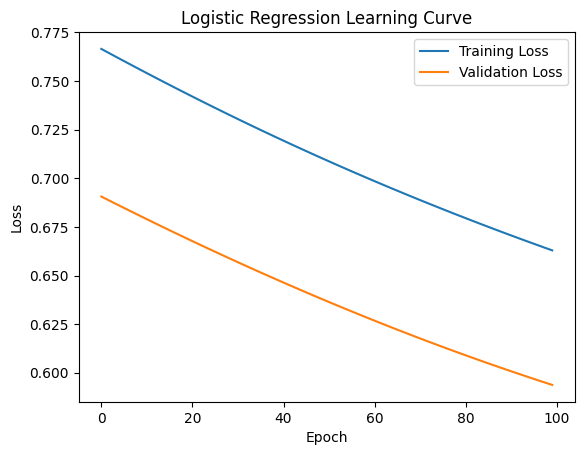

In [32]:
plt.figure()

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Logistic Regression Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()



# MLP Model with Hidden Layer

A **Multi‑Layer Perceptron (MLP)** introduces hidden layers and nonlinear activation functions.

Architecture used:

Input → Linear → ReLU → Linear → Sigmoid

ReLU activation:

f(x) = max(0, x)

This nonlinearity increases representational capacity compared to logistic regression.


In [40]:
class MLP(nn.Module):

    def __init__(self,input_dim,hidden=16):
        super().__init__()

        self.fc1 = nn.Linear(input_dim,hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.sigmoid(x)


mlp = MLP(X_train.shape[1],16)

criterion = nn.BCELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

train_loss=[]
val_loss=[]

for epoch in range(100):

    mlp.train()

    outputs = mlp(torch.tensor(X_train,dtype=torch.float32))

    loss = criterion(outputs.squeeze(),
                     torch.tensor(y_train.values,dtype=torch.float32))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

    mlp.eval()

    val_out = mlp(torch.tensor(X_val,dtype=torch.float32))

    vloss = criterion(val_out.squeeze(),
                      torch.tensor(y_val.values,dtype=torch.float32))

    val_loss.append(vloss.item())


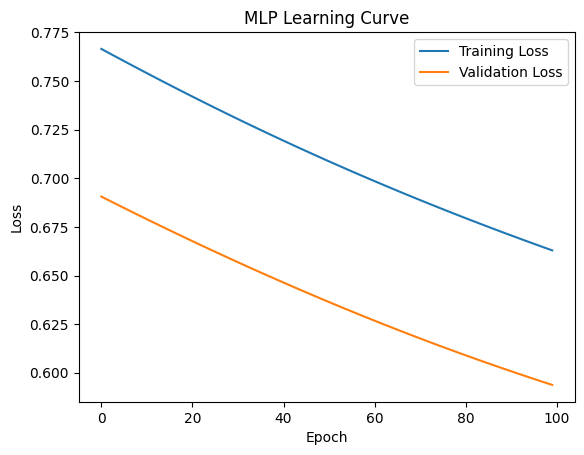

In [33]:
plt.figure()

plt.plot(train_loss,label="Training Loss")
plt.plot(val_loss,label="Validation Loss")

plt.title("MLP Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()



# Task 2 – Activation Function Comparison

We compare:

**ReLU**  
- faster convergence  
- sparse activation  
- risk of dead neurons

**tanh**  
- outputs between −1 and 1  
- smoother gradients  
- risk of **gradient saturation**


In [34]:
class MLP_Tanh(nn.Module):

    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# Train both models and plot


relu_model = MLP(X_train.shape[1],16)
tanh_model = MLP_Tanh(X_train.shape[1],16)

relu_loss=[]
tanh_loss=[]

criterion = nn.BCELoss()

opt_relu = optim.Adam(relu_model.parameters(),lr=0.001)
opt_tanh = optim.Adam(tanh_model.parameters(),lr=0.001)

for epoch in range(100):

    relu_model.train()
    out = relu_model(torch.tensor(X_train,dtype=torch.float32))
    loss = criterion(out.squeeze(),
                     torch.tensor(y_train.values,dtype=torch.float32))

    opt_relu.zero_grad()
    loss.backward()
    opt_relu.step()

    relu_loss.append(loss.item())

    tanh_model.train()
    out = tanh_model(torch.tensor(X_train,dtype=torch.float32))
    loss = criterion(out.squeeze(),
                     torch.tensor(y_train.values,dtype=torch.float32))

    opt_tanh.zero_grad()
    loss.backward()
    opt_tanh.step()

    tanh_loss.append(loss.item())



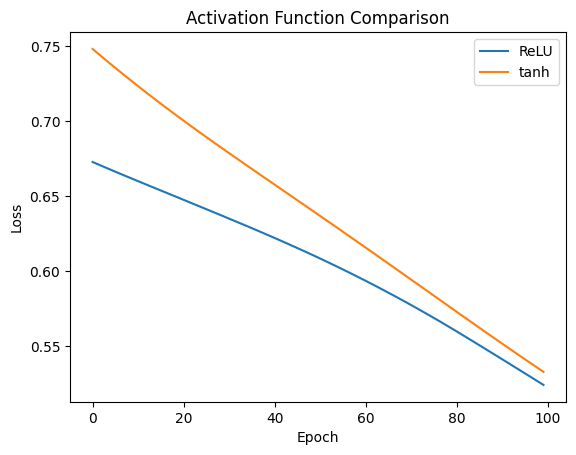

In [35]:
plt.figure()

plt.plot(relu_loss,label="ReLU")
plt.plot(tanh_loss,label="tanh")

plt.title("Activation Function Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()


**Capacity Comparison (8 vs 128 neurons)**

---



In [28]:
small = MLP(X_train.shape[1],8)
large = MLP(X_train.shape[1],128)

# train and plot

small_loss=[]
large_loss=[]

plt.plot(small_loss,label="Small Network")
plt.plot(large_loss,label="Large Network")

plt.title("Model Capacity Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()





Regularisation (L2 Weight Decay)

In [38]:
reg_model = MLP(X_train.shape[1],128)

optimizer = optim.Adam(
    reg_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


**Final Test Evaluation**

In [41]:
mlp.eval()

preds = mlp(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()

accuracy = accuracy_score(y_test,preds>0.5)
roc = roc_auc_score(y_test,preds)

print("Test Accuracy:",accuracy)
print("ROC AUC:",roc)


Test Accuracy: 0.7333333333333333
ROC AUC: 0.7258064516129032
